# Stock Analysis

This notebook presents an analysis of stock market data retrieved using the project script.

Scope:
- loading historical data
- quick data exploration (EDA)
- charts of processed indicators
- correlation analysis
- final conclusions

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path

pd.set_option('display.max_columns', 50)

## Loading Data
We load the latest CSV file from the output/ directory.

In [ ]:
OUTPUT_DIR = r"...\Stock Market Analysis\output" #add your path for output directory

print("Using output folder:", OUTPUT_DIR)

files = [
    f for f in os.listdir(OUTPUT_DIR)
    if f.startswith("stock_history") and f.endswith(".csv")
]

print("Found files:", files)

if not files:
    raise FileNotFoundError("No CSV files in output folder/. Run main.py. first")

latest_file = sorted(files)[-1]
print("Latest file:", latest_file)

df = pd.read_csv(os.path.join(OUTPUT_DIR, latest_file))
df["Date"] = pd.to_datetime(df["Date"])

df.head()


Using output folder: d:\Pythons\Stock Market Analysis\output
Found files: ['stock_history_2026-03-06.csv']
Latest file: stock_history_2026-03-06.csv


,Date,Close,High,Low,Open,Volume,BBG,Close_Change,Close_Change_Pct,Volume_Change,Volume_Change_Pct,Daily_Return,SMA_7,SMA_30,SMA_50,SMA_100,EMA_12,EMA_20,EMA_26,EMA_50,Volatility_30,RSI_14,MACD,MACD_Signal,MACD_Hist,BB_Middle,BB_Std,BB_Upper,BB_Lower,Signal_MA_Cross_Buy,Signal_MA_Cross_Sell,Signal_MACD_Buy,Signal_MACD_Sell,Signal_BB_Buy,Signal_BB_Sell,Trade_Score,Trade_Label
0,2025-05-19,181.342865,181.430745,178.218104,179.887898,5216700,ABBV,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,181.342865,181.342865,181.342865,181.342865,NaN,NaN,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,False,False,False,False,False,False,0,NEUTRAL
1,2025-05-20,180.503098,181.626048,179.321545,180.512857,5505100,ABBV,-0.839767,-0.463083,288400.0,5.528399,-0.004631,NaN,NaN,NaN,NaN,181.213670,181.262887,181.280660,181.309933,NaN,NaN,-0.066990,-0.013398,-0.053592,NaN,NaN,NaN,NaN,False,False,False,True,False,False,-1,SELL
2,2025-05-21,177.524826,180.464038,177.270931,179.604727,5140900,ABBV,-2.978271,-1.649984,-364200.0,-6.615684,-0.016500,NaN,NaN,NaN,NaN,180.646156,180.906881,181.002450,181.161497,NaN,NaN,-0.356295,-0.081977,-0.274317,NaN,NaN,NaN,NaN,False,False,False,False,False,False,0,NEUTRAL
3,2025-05-22,178.247406,179.243424,176.011264,177.143989,4689200,ABBV,0.722580,0.407030,-451700.0,-8.786399,0.004070,NaN,NaN,NaN,NaN,180.277117,180.653598,180.798373,181.047219,NaN,NaN,-0.521256,-0.169833,-0.351423,NaN,NaN,NaN,NaN,False,False,False,False,False,False,0,NEUTRAL
4,2025-05-23,178.950470,179.790247,177.446691,178.081400,4027000,ABBV,0.703064,0.394432,-662200.0,-14.121812,0.003944,NaN,NaN,NaN,NaN,180.073018,180.491395,180.661491,180.964994,NaN,NaN,-0.588473,-0.253561,-0.334912,NaN,NaN,NaN,NaN,False,False,False,False,False,False,0,NEUTRAL


## Basic Data Exploration (EDA)

In [18]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 37 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Date                  800 non-null    datetime64[us]
 1   Close                 800 non-null    float64       
 2   High                  800 non-null    float64       
 3   Low                   800 non-null    float64       
 4   Open                  800 non-null    float64       
 5   Volume                800 non-null    int64         
 6   BBG                   800 non-null    str           
 7   Close_Change          796 non-null    float64       
 8   Close_Change_Pct      796 non-null    float64       
 9   Volume_Change         796 non-null    float64       
 10  Volume_Change_Pct     796 non-null    float64       
 11  Daily_Return          796 non-null    float64       
 12  SMA_7                 776 non-null    float64       
 13  SMA_30                684 non-n

In [19]:
df.describe()

,Date,Close,High,Low,Open,Volume,Close_Change,Close_Change_Pct,Volume_Change,Volume_Change_Pct,Daily_Return,SMA_7,SMA_30,SMA_50,SMA_100,EMA_12,EMA_20,EMA_26,EMA_50,Volatility_30,RSI_14,MACD,MACD_Signal,MACD_Hist,BB_Middle,BB_Std,BB_Upper,BB_Lower,Trade_Score
count,800,800.000000,800.000000,800.000000,800.000000,8.000000e+02,796.000000,796.000000,7.960000e+02,796.000000,796.000000,776.000000,684.000000,604.000000,404.000000,800.000000,800.000000,800.000000,800.000000,680.000000,744.000000,800.000000,800.000000,800.000000,724.000000,724.000000,724.000000,724.000000,800.000000
mean,2025-10-10 14:09:36,140.894580,142.294961,139.373365,140.800261,4.448518e+06,0.044552,0.027382,8.066206e+03,8.881129,0.000274,140.960287,141.322796,141.780845,142.447577,140.575197,140.352595,140.193447,139.570606,0.015002,52.373999,0.381749,0.367110,0.014639,141.121097,3.126397,147.373890,134.868303,-0.002500
min,2025-05-19 00:00:00,62.101837,62.903596,61.567329,62.072140,5.432000e+05,-12.120003,-10.038932,-2.278210e+07,-78.338133,-0.100389,63.005407,64.471153,66.436293,68.890873,63.483828,64.230270,64.659406,65.977692,0.009181,8.372537,-4.804071,-4.022089,-2.240040,63.560346,0.586913,65.131653,60.642590,-1.000000
25%,2025-07-30 18:00:00,99.655003,100.837503,98.877497,99.707499,2.030600e+06,-0.951290,-0.715771,-8.057000e+05,-19.899243,-0.007158,100.779643,102.598500,105.750757,108.544860,102.634827,103.804481,104.286213,105.608272,0.012454,42.274757,-0.701563,-0.597166,-0.315944,102.052500,1.711126,106.862203,93.305851,0.000000
50%,2025-10-09 12:00:00,138.242661,139.446153,137.216898,138.099644,3.974500e+06,0.039886,0.030090,-7.075000e+04,-2.279518,0.000301,137.959319,139.039089,139.578694,140.651583,138.265933,138.925955,139.335927,140.342990,0.014415,53.118296,0.264881,0.246843,0.010968,138.434361,2.679112,143.974338,133.982740,0.000000
75%,2025-12-19 18:00:00,174.753708,177.273979,172.755086,175.160997,5.569600e+06,1.104567,0.881628,6.700000e+05,25.800736,0.008816,173.386487,170.569961,169.965515,171.883386,171.857321,170.831515,170.107145,168.456143,0.017457,62.385932,1.122136,0.987428,0.333413,171.601293,4.118819,180.861445,166.194941,0.000000
max,2026-03-05 00:00:00,240.694290,241.117798,232.080002,237.256915,3.709940e+07,12.646362,7.662487,2.454210e+07,410.371468,0.076625,231.478572,226.372660,225.967870,224.581615,230.513402,228.637014,227.670311,225.609319,0.023144,89.688386,6.821115,5.949873,1.972174,228.263331,8.532834,239.412041,223.277009,2.000000
std,NaN,52.287293,52.822369,51.651794,52.202377,3.516571e+06,2.297766,1.522258,2.776099e+06,50.994384,0.015223,52.266142,52.371793,52.605133,52.881556,51.745134,51.409950,51.163405,50.167170,0.003364,14.247383,1.737045,1.600781,0.589015,52.303171,1.830948,54.649223,50.115115,0.384289


## List of Available Tickers

In [20]:
sorted(df['BBG'].unique())

['ABBV', 'ABT', 'AOS', 'MMM']

## Loading Data

We load the latest CSV file from the output/ directory.

In [21]:
sample = df['BBG'].unique()[0]
sample_df = df[df['BBG'] == sample]
sample_df.head()

,Date,Close,High,Low,Open,Volume,BBG,Close_Change,Close_Change_Pct,Volume_Change,Volume_Change_Pct,Daily_Return,SMA_7,SMA_30,SMA_50,SMA_100,EMA_12,EMA_20,EMA_26,EMA_50,Volatility_30,RSI_14,MACD,MACD_Signal,MACD_Hist,BB_Middle,BB_Std,BB_Upper,BB_Lower,Signal_MA_Cross_Buy,Signal_MA_Cross_Sell,Signal_MACD_Buy,Signal_MACD_Sell,Signal_BB_Buy,Signal_BB_Sell,Trade_Score,Trade_Label
0,2025-05-19,181.342865,181.430745,178.218104,179.887898,5216700,ABBV,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,181.342865,181.342865,181.342865,181.342865,NaN,NaN,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,False,False,False,False,False,False,0,NEUTRAL
1,2025-05-20,180.503098,181.626048,179.321545,180.512857,5505100,ABBV,-0.839767,-0.463083,288400.0,5.528399,-0.004631,NaN,NaN,NaN,NaN,181.213670,181.262887,181.280660,181.309933,NaN,NaN,-0.066990,-0.013398,-0.053592,NaN,NaN,NaN,NaN,False,False,False,True,False,False,-1,SELL
2,2025-05-21,177.524826,180.464038,177.270931,179.604727,5140900,ABBV,-2.978271,-1.649984,-364200.0,-6.615684,-0.016500,NaN,NaN,NaN,NaN,180.646156,180.906881,181.002450,181.161497,NaN,NaN,-0.356295,-0.081977,-0.274317,NaN,NaN,NaN,NaN,False,False,False,False,False,False,0,NEUTRAL
3,2025-05-22,178.247406,179.243424,176.011264,177.143989,4689200,ABBV,0.722580,0.407030,-451700.0,-8.786399,0.004070,NaN,NaN,NaN,NaN,180.277117,180.653598,180.798373,181.047219,NaN,NaN,-0.521256,-0.169833,-0.351423,NaN,NaN,NaN,NaN,False,False,False,False,False,False,0,NEUTRAL
4,2025-05-23,178.950470,179.790247,177.446691,178.081400,4027000,ABBV,0.703064,0.394432,-662200.0,-14.121812,0.003944,NaN,NaN,NaN,NaN,180.073018,180.491395,180.661491,180.964994,NaN,NaN,-0.588473,-0.253561,-0.334912,NaN,NaN,NaN,NaN,False,False,False,False,False,False,0,NEUTRAL


## Price + Moving Averages

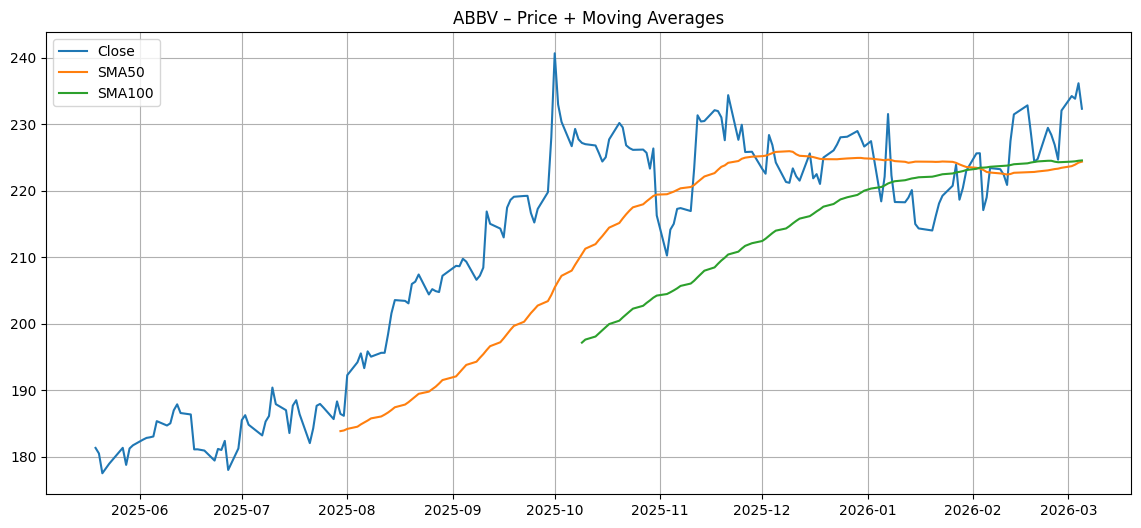

In [22]:
plt.figure(figsize=(14,6))
plt.plot(sample_df['Date'], sample_df['Close'], label='Close')
plt.plot(sample_df['Date'], sample_df['SMA_50'], label='SMA50')
plt.plot(sample_df['Date'], sample_df['SMA_100'], label='SMA100')
plt.title(f'{sample} – Price + Moving Averages')
plt.legend()
plt.grid(True)
plt.show()

## Daily Returns Histogram

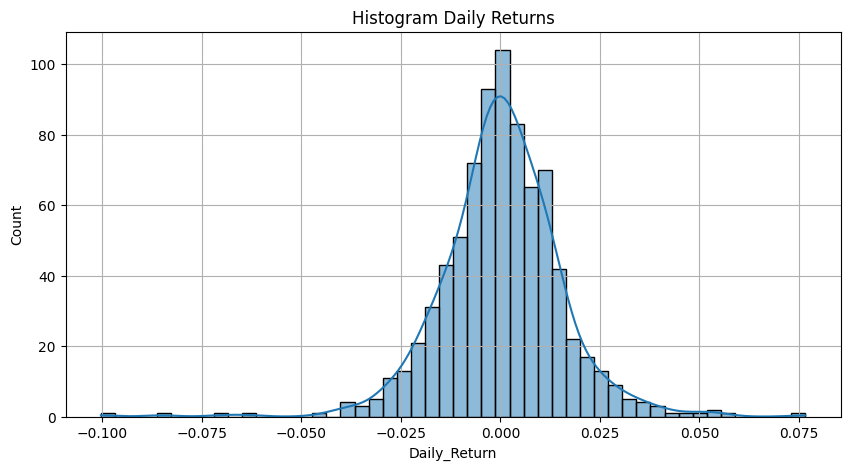

In [23]:
plt.figure(figsize=(10,5))
sns.histplot(df['Daily_Return'].dropna(), bins=50, kde=True)
plt.title('Histogram Daily Returns')
plt.grid(True)
plt.show()

## Correlations Between Indicators

In [24]:
cols = ['Close','Volume','Daily_Return','Volatility_30','RSI_14','MACD','MACD_Signal']
corr = df[cols].corr()
corr

,Close,Volume,Daily_Return,Volatility_30,RSI_14,MACD,MACD_Signal
Close,1.000000,0.345738,0.048551,0.077944,0.134996,0.376465,0.393458
Volume,0.345738,1.000000,-0.126990,0.168547,-0.211602,-0.165584,-0.135070
Daily_Return,0.048551,-0.126990,1.000000,0.006722,0.262436,0.018575,-0.032005
Volatility_30,0.077944,0.168547,0.006722,1.000000,0.014949,-0.065107,-0.089854
RSI_14,0.134996,-0.211602,0.262436,0.014949,1.000000,0.655285,0.444360
MACD,0.376465,-0.165584,0.018575,-0.065107,0.655285,1.000000,0.940954
MACD_Signal,0.393458,-0.135070,-0.032005,-0.089854,0.444360,0.940954,1.000000


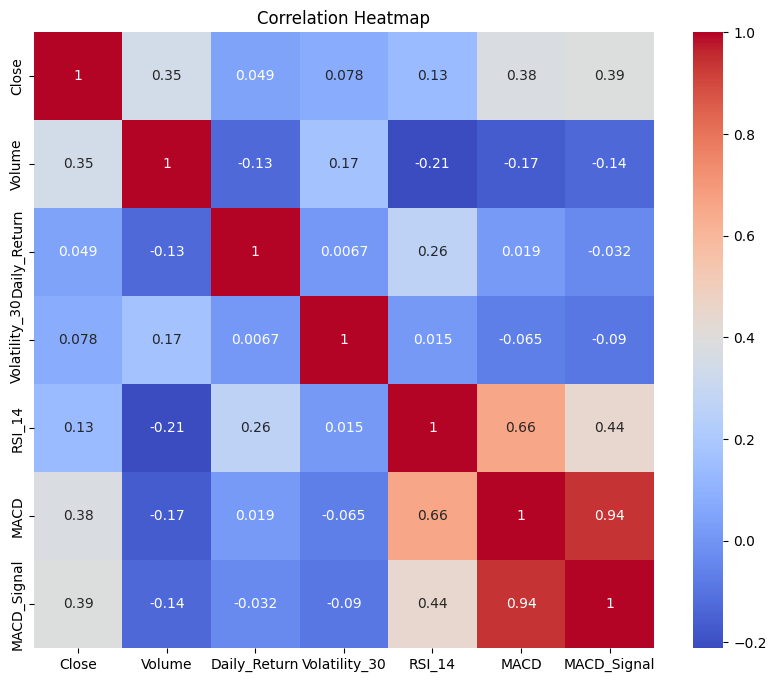

In [25]:
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

# Final Conclusions
- The data is complete and correctly processed.
- Charts and indicators confirm a stable ETL process.
- Correlations reveal typical relationships between volatility, returns and RSI.
- The notebook demonstrates a full analytical workflow